<a href="https://colab.research.google.com/github/infante-manu/unav-data-cleaning-and-preparation/blob/NO-ISSUE%2Funderstanding-and-examine-data/Practice_churn_prediction__alfaro_infante.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import DataSet


### Importing Libraries

In [ ]:
import kagglehub
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression # Import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score,classification_report

# Read the Data

## Food Delivery Order History Data

A Comprehensive Dataset on Restaurant Orders & Customer Preferences -> [kaggle](https://www.kaggle.com/datasets/sujalsuthar/food-delivery-order-history-data)

This dataset contains 21,321 food order records from various restaurants, capturing crucial details about customer preferences, order trends, pricing, and delivery performance. It includes 6 unique imaginary restaurants, such as Swaad, Aura Pizzas, Dilli Burger Adda, Tandoori Junction, The Chicken Junction, and Masala Junction. The dataset provides a comprehensive view of food delivery operations, making it highly valuable for data analysis, predictive modeling, and machine learning applications.

Key attributes in this dataset include restaurant details (restaurant name, subzone, city), order information (order ID, timestamps, order status, delivery time, distance, number of items), pricing breakdown (bill subtotal, packaging charges, total cost, discounts), and customer feedback (ratings, reviews, order cancellations). It also tracks key delivery insights such as rider wait time, preparation duration, and distance traveled, which can be useful for logistics optimization and demand forecasting.

This dataset can be leveraged for predicting delivery times, analyzing customer behavior, identifying top-performing restaurants, and optimizing pricing strategies. It is particularly useful for food delivery platforms, restaurant managers, and data scientists looking to improve delivery efficiency and customer satisfaction. With rich historical data, this dataset can also be used for building recommendation systems, identifying peak ordering times, and enhancing user experience in food delivery applications.

In [ ]:
# Get Data
path = kagglehub.dataset_download("sujalsuthar/food-delivery-order-history-data")
data = pd.read_csv(path + "/order_history_kaggle_data.csv")

NameError: name 'kagglehub' is not defined

In [ ]:
# Rename of the columns names for easy use
data.columns = data.columns.\
    str.lower().\
    str.replace('/', '').\
    str.replace('(', '').\
    str.replace(')', '').\
    str.replace(' ', '_')

data.head(10)

# Understanding and examinate Data

| Column Name                                          | Description                                                     |
|------------------------------------------------------|-----------------------------------------------------------------|
| `Restaurant ID`                                      | Unique ID assigned to each restaurant                           |
| `Restaurant name`                                    | Name of the restaurant (e.g., Swaad, Aura Pizzas, Dilli Burger Adda) |
| `Subzone`                                            | Location subzone of the restaurant                              |
| `City`                                               | City where the restaurant is located                            |
| `Order ID`                                           | Unique identifier for each order                                |
| `Order Placed At`                                    | Timestamp when the order was placed                             |
| `Order Status`                                       | Status of the order (Delivered, Canceled, Rejected, In Progress)|
| `Delivery`                                           | Mode of delivery (Zomato Delivery, Self Pickup, etc.)           |
| `Distance`                                           | Distance between restaurant and customer (e.g., <1km, 2km, 5km) |
| `Items in order`                                     | List of food items ordered                                      |
| `Instructions`                                       | Special instructions provided by the customer                   |
| `Discount construct`                                 | Structure/details of discounts applied                          |
| `Bill subtotal`                                      | Subtotal amount before additional charges/discounts             |
| `Packaging charges`                                  | Additional packaging fee applied                                |
| `Restaurant discount (Promo)`                        | Discount provided by the restaurant as promotional offer        |
| `Restaurant discount (Flat offs, Freebies & others)` | Discounts by restaurant (flat rates, freebies, others)          |
| `Gold discount`                                      | Special discount for Zomato Gold members                        |
| `Brand pack discount`                                | Discount provided for brand-specific packaging                  |
| `Total`                                              | Final total payable amount after discounts and charges          |
| `Rating`                                             | Customer's rating for the order                                 |
| `Review`                                             | Customer's textual feedback/review                              |
| `Cancellation / Rejection reason`                    | Reason provided for order cancellation or rejection             |
| `Restaurant compensation (Cancellation)`             | Amount compensated by restaurant for cancellations              |
| `Restaurant penalty (Rejection)`                     | Penalty charged to restaurant for order rejection               |
| `KPT duration (minutes)`                             | Kitchen Preparation Time duration (minutes)                     |
| `Rider wait time (minutes)`                          | Duration rider waited at restaurant (minutes)                   |
| `Order Ready Marked`                                 | Tag Indicating if the Order Ready was marked (Correctly, Incorrectly, Missed)                       |
| `Customer complaint tag`                             | Tag indicating type of customer complaint                       |
| `Customer ID`                                        | Unique identifier for the customer                              |


## Fixing data types

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 29 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   restaurant_id                                     21321 non-null  int64  
 1   restaurant_name                                   21321 non-null  object 
 2   subzone                                           21321 non-null  object 
 3   city                                              21321 non-null  object 
 4   order_id                                          21321 non-null  int64  
 5   order_placed_at                                   21321 non-null  object 
 6   order_status                                      21321 non-null  object 
 7   delivery                                          21321 non-null  object 
 8   distance                                          21321 non-null  object 
 9   items_in_order   

In [ ]:
df = data.copy()
df = df.rename(columns = {"restaurant_discount_flat_offs,_freebies_&_others" : "restaurant_discount_flat_offs"})

# DATE Related Features

# Convert order_placed_at to datetime
df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])
# Extract date related features
df['order_month'] = df['order_placed_at'].dt.month
df['order_day'] = df['order_placed_at'].dt.day
df['order_hour'] = df['order_placed_at'].dt.hour
df['order_dayofweek'] = df['order_placed_at'].dt.dayofweek
df['order_weekofyear'] = df['order_placed_at'].dt.isocalendar().week


df = df.sort_values("order_placed_at")
df["cum_count"] =  df.groupby("customer_id").cumcount()
df["orders_after"] = df[::-1].groupby("customer_id").cumcount() # Count how many orders are placed after each order
df["has_not_reorder"] = df["orders_after"] == 0 # Flag if there is at least one order after this order

#DISTANCE FORMATTING
df["distance"] = df["distance"].\
    str.replace("<1", "0.5").\
    str.replace("km", "").astype(float)

#  MEAN TICKET
df['number_of_products'] = df['items_in_order'].apply(lambda x: sum(int(i.split('x')[0].strip()) for i in str(x).split(',')))
df['mean_product_value'] = df['total'] / df['number_of_products']

#  FROM TEXT INPUT TO BOOLEAN
text_to_boolean = ["review", "instructions"]
df[[f"has_{col}"for col in text_to_boolean]] = ~ df[text_to_boolean].isna()

# DISCOUNT SHARES
for discount in df.columns[df.columns.str.contains("discount")][1:]:
    discount_share = discount + "_share"
    print(f"{discount} -> {discount_share}")
    df[discount_share] = np.where(df[discount] == 0, 0,df["total"] / df[discount])
    df.drop(columns = discount, inplace = True)


/var/folders/rt/18741j210gv901hc68y39qm80000gp/T/ipykernel_90024/2692813110.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])


restaurant_discount_promo -> restaurant_discount_promo_share
restaurant_discount_flat_offs -> restaurant_discount_flat_offs_share
gold_discount -> gold_discount_share
brand_pack_discount -> brand_pack_discount_share


In [ ]:
temp = data.columns

df=  df[
[
    "order_id",
    "restaurant_name",
    "subzone",
    "order_placed_at" ,
    "order_month",
    "order_day",
    "order_hour",
    "order_dayofweek",
    "order_weekofyear",
    "order_status",
    "delivery",
    "distance",
    "bill_subtotal",
    "packaging_charges",
    "total",
    "rating",
    "cancellation__rejection_reason",
    "restaurant_compensation_cancellation",
    "restaurant_penalty_rejection",
    "kpt_duration_minutes",
    "rider_wait_time_minutes",
    "order_ready_marked",
    "customer_complaint_tag",
    "number_of_products",
    "mean_product_value",
    "has_review",
    "has_instructions",
    "restaurant_discount_promo_share",
    "restaurant_discount_flat_offs_share",
    "gold_discount_share" ,
    "brand_pack_discount_share",
    "has_not_reorder"
]]

In [ ]:
[col for col in temp if col not in df.columns]

['restaurant_id',
 'city',
 'items_in_order',
 'instructions',
 'discount_construct',
 'restaurant_discount_promo',
 'restaurant_discount_flat_offs,_freebies_&_others',
 'gold_discount',
 'brand_pack_discount',
 'review',
 'customer_id']

In [ ]:
# Example of customer with multiple orders
#df.loc[
 # df["customer_id"] == df.query("orders_after == 8")["customer_id"].iloc[0], :
  #].\
  #sort_values("order_placed_at").\
#loc[:, ["order_placed_at", "cum_count", "has_not_reorder", "orders_after"]]


In [ ]:
#df = df.query("cum_count == 0") # Keep only the first order of each customer

## Check the statistical values of features

In [ ]:
#df.numericas = df.select_dtypes(include=['int64', 'float64'])
#df.categoricas = df.select_dtypes(include=['object'])
df.numeric_features = df.select_dtypes(include=['int64', 'float64'])
#df.numeric_features = df.numeric_features.drop(columns=["cum_count", "order_id"])
df.categorical_features = df.select_dtypes(include=['object'])

/var/folders/rt/18741j210gv901hc68y39qm80000gp/T/ipykernel_90024/916521652.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.numeric_features = df.select_dtypes(include=['int64', 'float64'])
/var/folders/rt/18741j210gv901hc68y39qm80000gp/T/ipykernel_90024/916521652.py:5: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.categorical_features = df.select_dtypes(include=['object'])


In [ ]:
df.numeric_features

,order_id,distance,bill_subtotal,packaging_charges,total,rating,restaurant_compensation_cancellation,restaurant_penalty_rejection,kpt_duration_minutes,rider_wait_time_minutes,number_of_products,mean_product_value,restaurant_discount_promo_share,restaurant_discount_flat_offs_share,gold_discount_share,brand_pack_discount_share
584,6139801139,3.0,788.0,33.80,709.80,1.0,NaN,NaN,19.58,1.1,2,354.9000,6.337500,0.000000,0.0,0.0
835,6134954975,2.0,259.0,8.00,168.00,NaN,NaN,NaN,10.87,1.1,1,168.0000,1.696970,0.000000,0.0,0.0
834,6140763362,8.0,1204.0,55.55,1166.55,NaN,NaN,NaN,15.82,1.2,4,291.6375,12.543548,0.000000,0.0,0.0
127,6128060895,2.0,310.0,10.50,220.50,NaN,NaN,NaN,14.87,3.0,1,220.5000,2.205000,0.000000,0.0,0.0
833,6139906104,6.0,659.0,28.30,594.30,NaN,NaN,NaN,13.00,1.0,1,594.3000,6.390323,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20790,6571788500,1.0,839.0,20.98,440.48,NaN,NaN,NaN,19.13,0.6,1,440.4800,0.000000,1.050012,0.0,0.0
19804,6572395200,1.0,310.0,15.50,325.50,NaN,NaN,NaN,18.08,1.1,2,162.7500,0.000000,0.000000,0.0,0.0
20789,6567469287,3.0,569.0,14.23,298.73,5.0,NaN,NaN,16.32,1.0,1,298.7300,0.000000,1.050018,0.0,0.0
19940,6571201675,2.0,375.0,18.75,393.75,NaN,NaN,NaN,22.55,0.3,2,196.8750,0.000000,0.000000,0.0,0.0


## Data Exploring

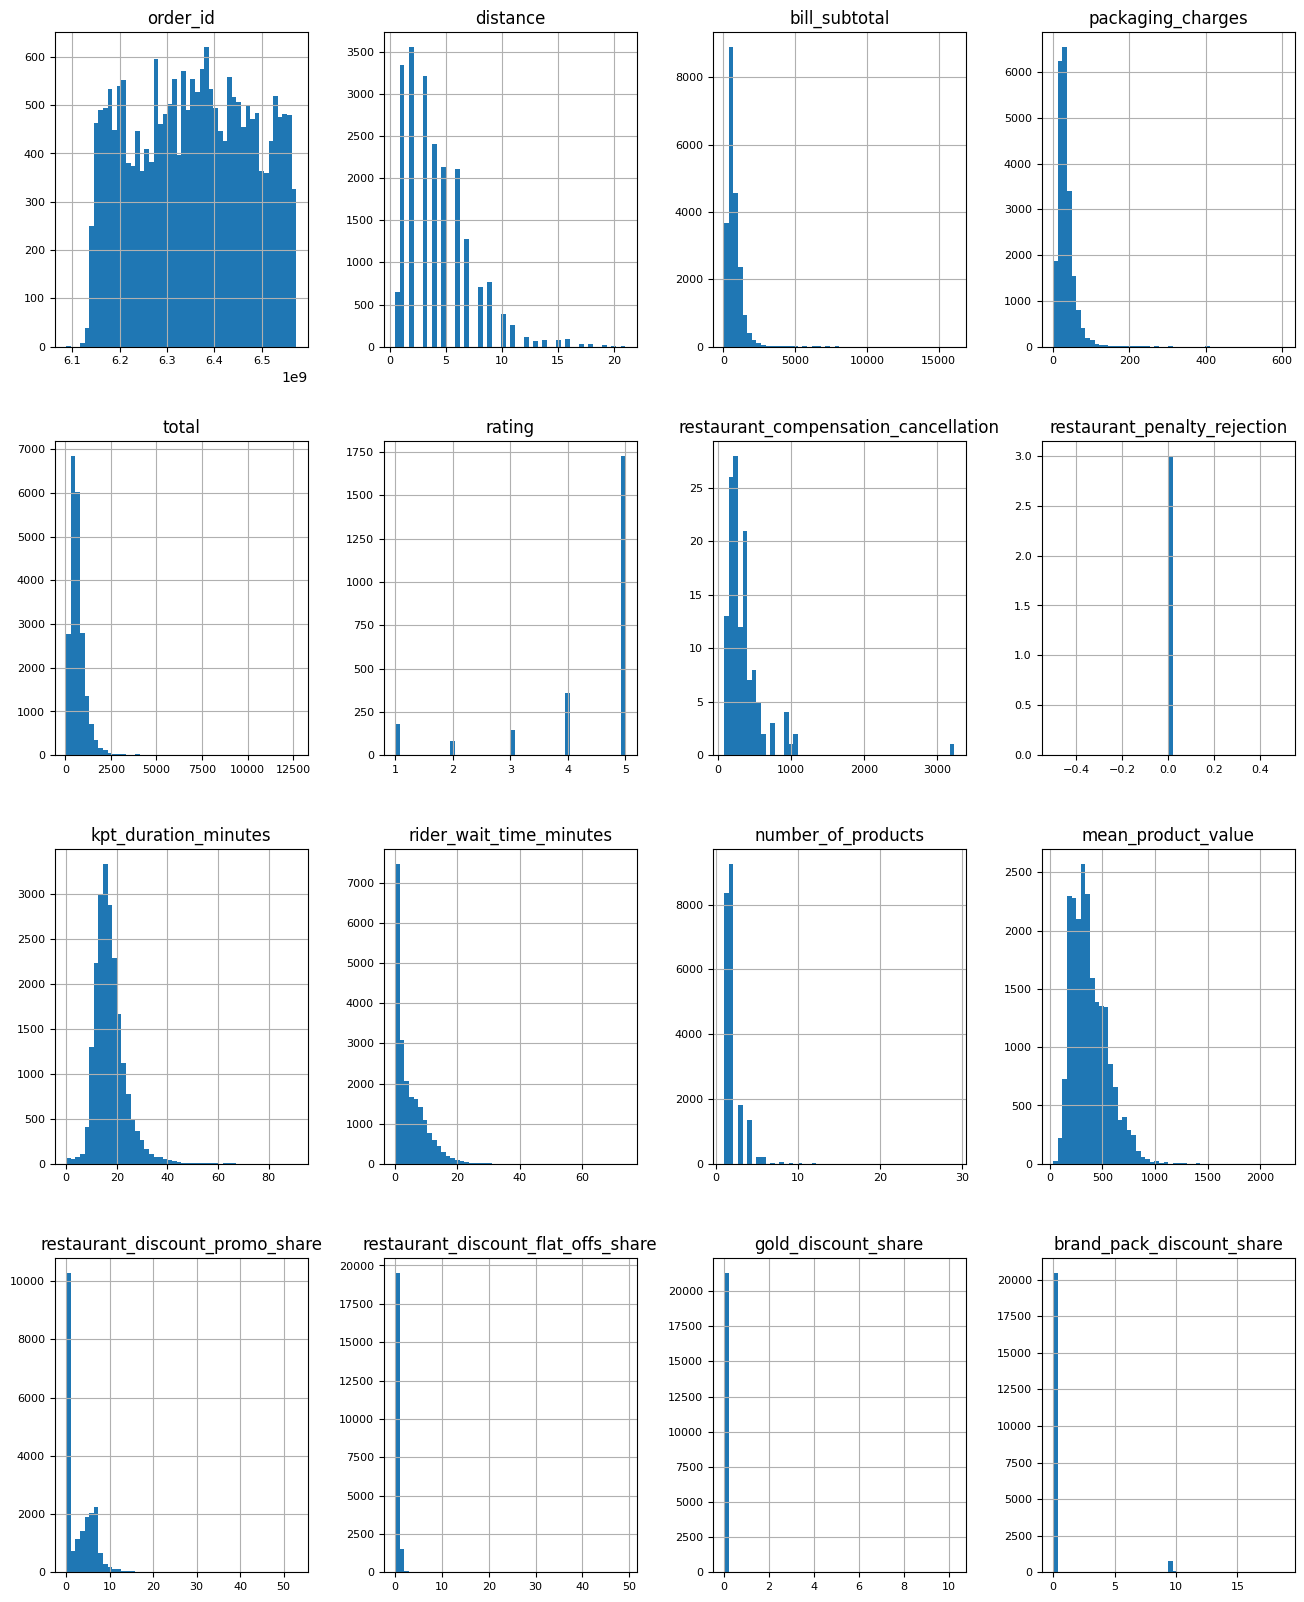

In [ ]:

df.numeric_features.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)
plt.show()

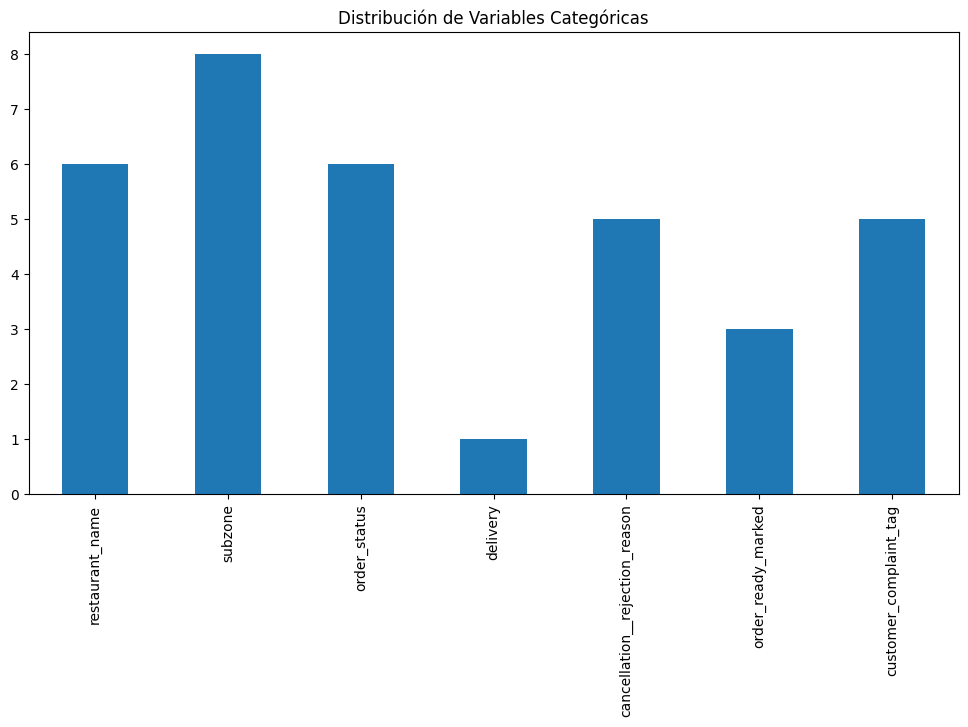

In [ ]:
df.categorical_features.nunique().plot(kind='bar', figsize=(12, 6), title="Distribución de Variables Categóricas")
plt.show()


In [ ]:
print(df.categorical_features.nunique())


restaurant_name                   6
subzone                           8
order_status                      6
delivery                          1
cancellation__rejection_reason    5
order_ready_marked                3
customer_complaint_tag            5
dtype: int64


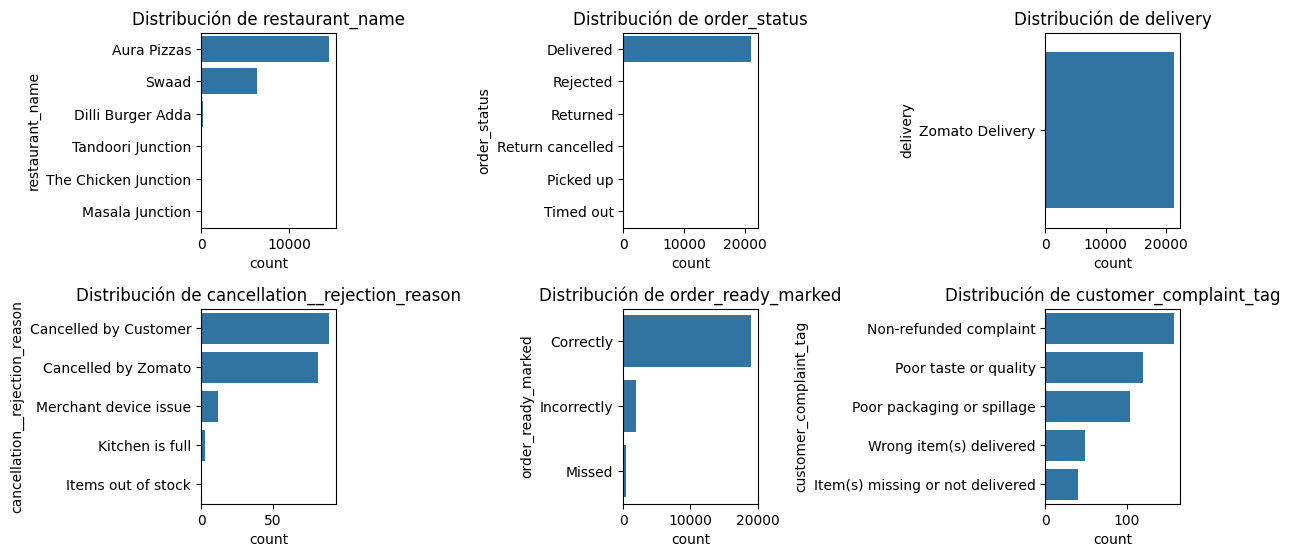

In [ ]:
categorical_limited = df.categorical_features.nunique()
columns_to_plot = categorical_limited[categorical_limited <= 7].index

# Graficar distribución de cada variable filtrada
plt.figure(figsize=(12, 8))
for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(3, 3, i)  # Ajustar el tamaño si hay más de 6
    # Changed 'df.categoricas_features' to 'df.categorical_features'
    sns.countplot(y=df.categorical_features[col], order=df.categorical_features[col].value_counts().index)
    plt.title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

# Creating new variables


In [ ]:
#compra_frecuencia = df.groupby('Customer ID').size().reset_index(name='Total_Compras')
#print(compra_frecuencia.sort_values('Total_Compras', ascending=False))

In [ ]:
#compra_frecuencia['Recompra'] = (compra_frecuencia['Total_Compras'] >= 2).astype(int)


In [ ]:
# Paso 3: Unir la variable "Recompra" al dataset original sin eliminar compras adicionales
#df_target = df.merge(compra_frecuencia[['Customer ID', 'Recompra']], on='Customer ID', how='left')

In [ ]:
#df_target.shape

In [ ]:
# Contar la cantidad de clientes en cada clase
#plt.figure(figsize=(6,4))
#sns.countplot(x=df['has_not_reorder'])
#plt.title("Distribución de la Variable Recompra")
#plt.xlabel("Recompra (0 = No, 1 = Sí)")
#plt.ylabel("Cantidad de Clientes")
#plt.show()

In [ ]:
# Plot with FacetGrid
#df_filtered = df[df["CumCount"] <= 11]


In [ ]:
#df_filtered

In [ ]:
#g = sns.FacetGrid(df_filtered, col="CumCount", col_wrap=4, sharey=True)
#g.map(sns.countplot, "has_not_reorder", order=[False, True], stat='percent')

# Labeling
#plt.subplots_adjust(top=0.85)
#g.fig.suptitle("Distribución de la Variable Recompra por Cantidad de Pedidos Previos", fontsize=14)

# Set x and y labels correctly


#plt.show()


In [ ]:
# g = sns.FacetGrid(df_filtered, col="CumCount", col_wrap=4, sharey=True)
# g.map(sns.countplot, "has_not_reorder", order=[False, True], stat = 'percent')

# # Labeling
# plt.subplots_adjust(top=0.85)
# g.fig.suptitle("Distribución de la Variable Recompra por Cantidad de Pedidos Previos")
# g.set_axis_labels("Recompra (0 = No, 1 = Sí)", "Porcentaje de Clientes")
# for ax in g.axes.flatten():
#     ax.set_xlabel("Recompra (0 = No, 1 = Sí)")
#     ax.set_ylabel("Cantidad de Clientes")

# plt.show()

In [ ]:
# df['Customer complaint tag'].value_counts().reset_index() #No vale la pena trabajar esta OK

# Data Split

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['has_not_reorder'], random_state=42)

train_df['has_not_reorder'].value_counts().reset_index()


,has_not_reorder,count
0,True,9285
1,False,7771


In [ ]:
test_df['has_not_reorder'].value_counts().reset_index()

,has_not_reorder,count
0,True,2322
1,False,1943


# Data Transform

## Cheking Data

In [ ]:
train_df.isnull().sum()

order_id                                    0
restaurant_name                             0
subzone                                     0
order_placed_at                             0
order_month                                 0
order_day                                   0
order_hour                                  0
order_dayofweek                             0
order_weekofyear                            0
order_status                                0
delivery                                    0
distance                                    0
bill_subtotal                               0
packaging_charges                           0
total                                       0
rating                                  15047
cancellation__rejection_reason          16910
restaurant_compensation_cancellation    16951
restaurant_penalty_rejection            17054
kpt_duration_minutes                      236
rider_wait_time_minutes                   134
order_ready_marked                

### Mising Values

In [ ]:
## drop
train_df.drop(columns=['order_placed_at'], inplace=True)
test_df.drop(columns=['order_placed_at'], inplace=True)

In [ ]:
from sklearn.impute import SimpleImputer
SimpleImputer

# Mising Values of Penalty Rejection = No rejection
train_df['restaurant_penalty_rejection'] = train_df['restaurant_penalty_rejection'].fillna(0)
test_df['restaurant_penalty_rejection'] = test_df['restaurant_penalty_rejection'].fillna(0)
train_df['restaurant_penalty_rejection'].isnull().sum()

np.int64(0)

In [ ]:

# Mising Values of cancellation = No cancellation
train_df['cancellation__rejection_reason'] = train_df['cancellation__rejection_reason'].fillna('not cancellation')
test_df['cancellation__rejection_reason'] = test_df['cancellation__rejection_reason'].fillna('not cancellation')
train_df['cancellation__rejection_reason'].value_counts().reset_index()

,cancellation__rejection_reason,count
0,not cancellation,16910
1,Cancelled by Customer,72
2,Cancelled by Zomato,63
3,Merchant device issue,9
4,Kitchen is full,1
5,Items out of stock,1


In [ ]:

# Mising Values of complaing tag = No coments
train_df['customer_complaint_tag'] = train_df['customer_complaint_tag'].fillna('not coments')
test_df['customer_complaint_tag'] = test_df['customer_complaint_tag'].fillna('not coments')
train_df['customer_complaint_tag'].value_counts().reset_index()

,customer_complaint_tag,count
0,not coments,16698
1,Non-refunded complaint,116
2,Poor taste or quality,95
3,Poor packaging or spillage,80
4,Wrong item(s) delivered,36
5,Item(s) missing or not delivered,31


In [ ]:
from sklearn.impute import KNNImputer

# selection variables to impute
coloms_to_impute = ['rider_wait_time_minutes','kpt_duration_minutes']
#knn Selection
knn_imputer = KNNImputer(n_neighbors=5)
## imputing
train_df[coloms_to_impute] = knn_imputer.fit_transform(train_df[coloms_to_impute])

test_df[coloms_to_impute] = knn_imputer.transform(test_df[coloms_to_impute])

In [ ]:
## reestaurante compensation Null = no cancellation , no compensation = 0
train_df['restaurant_compensation_cancellation'] = train_df['restaurant_compensation_cancellation'].fillna(0)
test_df['restaurant_compensation_cancellation'] = test_df['restaurant_compensation_cancellation'].fillna(0)
train_df['restaurant_compensation_cancellation'].isnull().sum()

np.int64(0)

In [ ]:
# Mapear valores numéricos a etiquetas
rating_map = {
    1.0: "Muy Mala",
    2.0: "Mala",
    3.0: "Regular",
    4.0: "Buena",
    5.0: "Excelente"
}

# Aplicar el mapeo y manejar los nulos
train_df['rating'] = train_df['rating'].map(rating_map).fillna("No Calification")
test_df['rating'] = test_df['rating'].map(rating_map).fillna("No Calification")

# Convertir a tipo categórico asegurando el orden
categorias_rating = ["Muy Mala", "Mala", "Regular", "Buena", "Excelente", "No Calification"]
train_df['rating'] = pd.Categorical(train_df['rating'], categories=categorias_rating, ordered=True)
test_df['rating'] = pd.Categorical(test_df['rating'], categories=categorias_rating, ordered=True)


In [ ]:
train_df['rating'].value_counts().reset_index()


#plt(show)

,rating,count
0,No Calification,15047
1,Excelente,1386
2,Buena,295
3,Muy Mala,149
4,Regular,114
5,Mala,65


In [ ]:
train_df['rating'].dtype
#train_df.isnull().sum()

CategoricalDtype(categories=['Muy Mala', 'Mala', 'Regular', 'Buena', 'Excelente',
                  'No Calification'],
, ordered=True, categories_dtype=object)

## Normalize

### Numerical

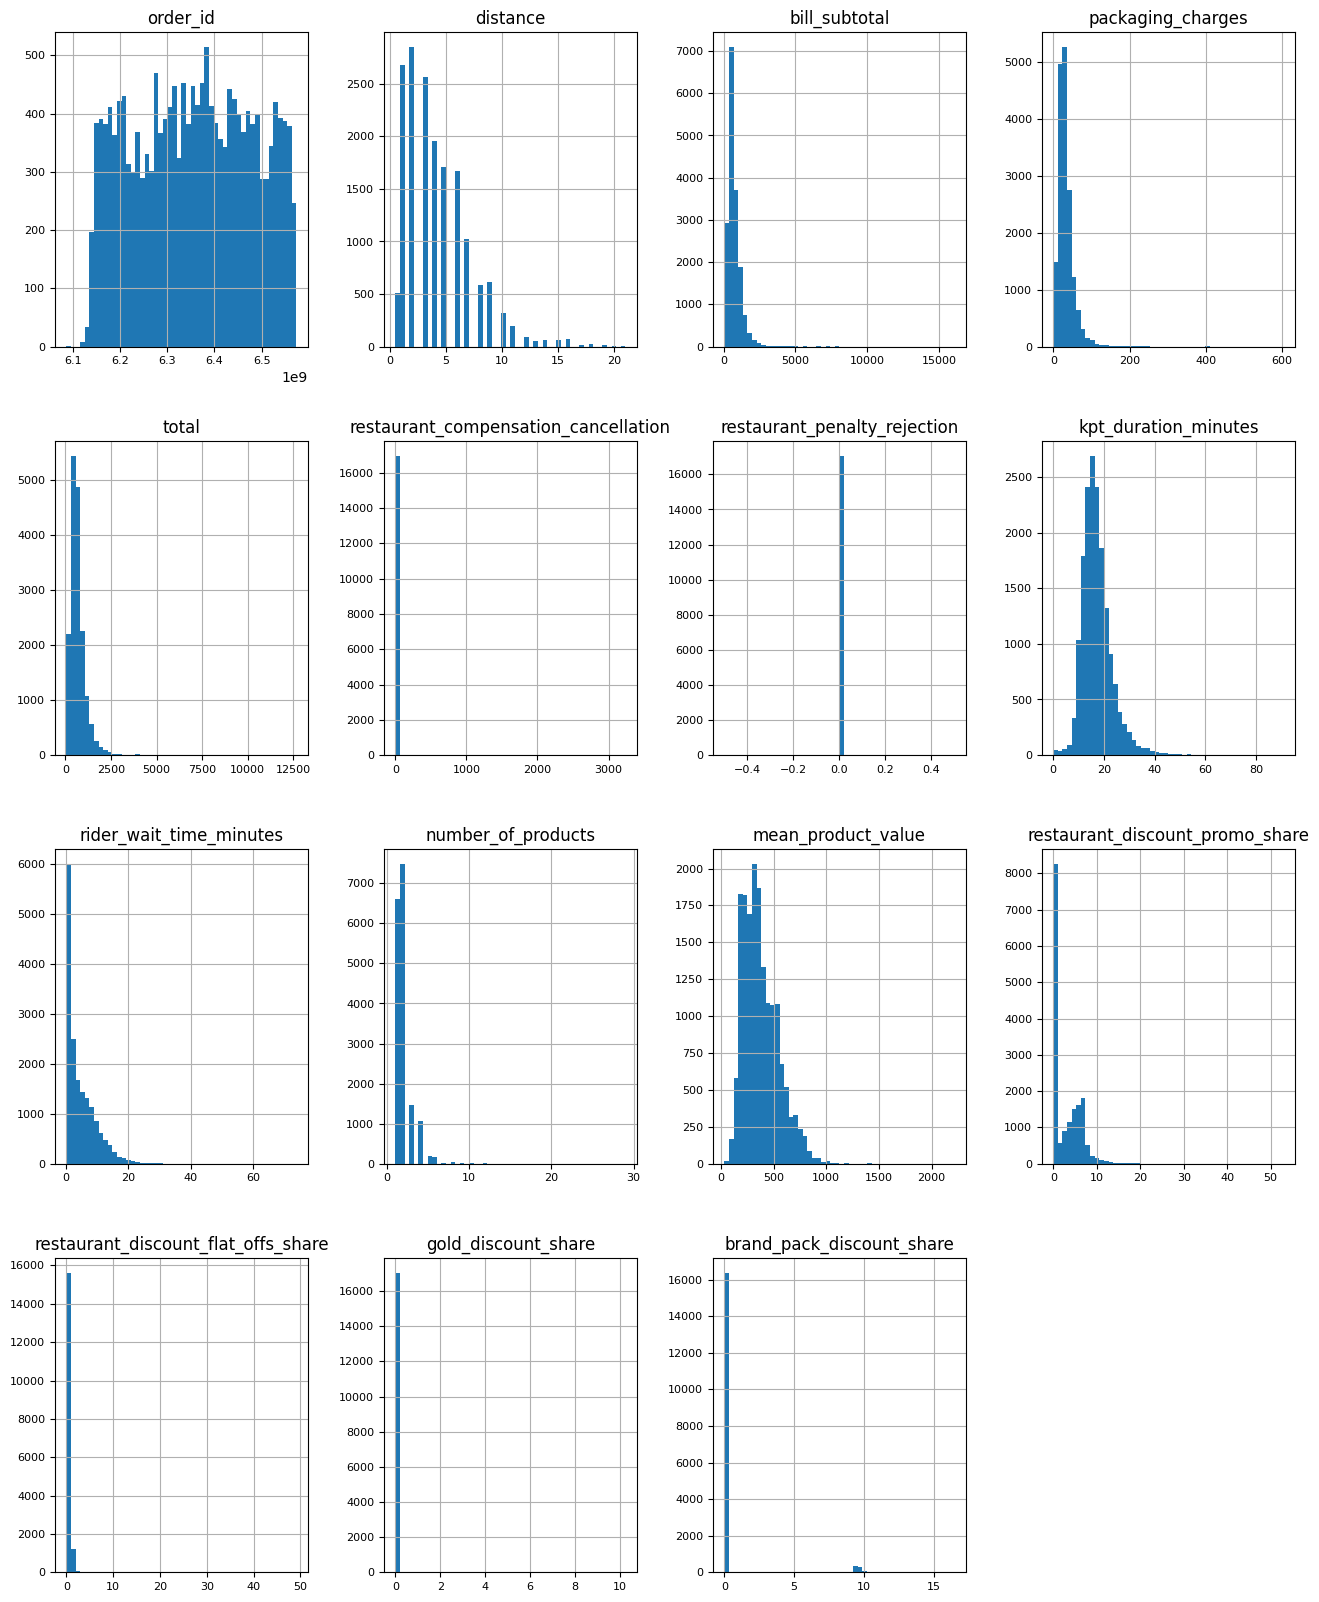

In [ ]:
train_df.select_dtypes(include=['int64', 'float64']).hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)
plt.show()

In [ ]:
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

# Inicializar el escalador
scaler = MinMaxScaler()

# Ajustar en train y transformar en train y test
train_df[numerical_cols] = scaler.fit_transform(train_df[numerical_cols])
test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])


###Categorical

In [ ]:
# from sklearn.preprocessing import StandardScaler

# # Seleccionar solo columnas numéricas
# numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

# # Inicializar el escalador
# scaler = StandardScaler()

# # Ajustar en train y transformar en train
# train_df[numerical_cols] = scaler.fit_transform(train_df[numerical_cols])


# # Verificar la normalización
# train_df.select_dtypes(include=['int64', 'float64']).head()


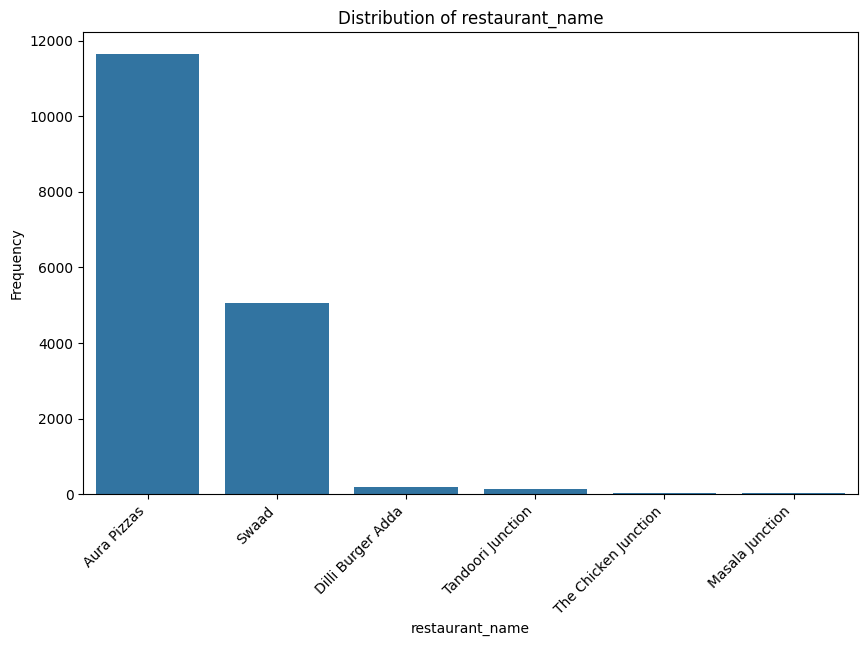

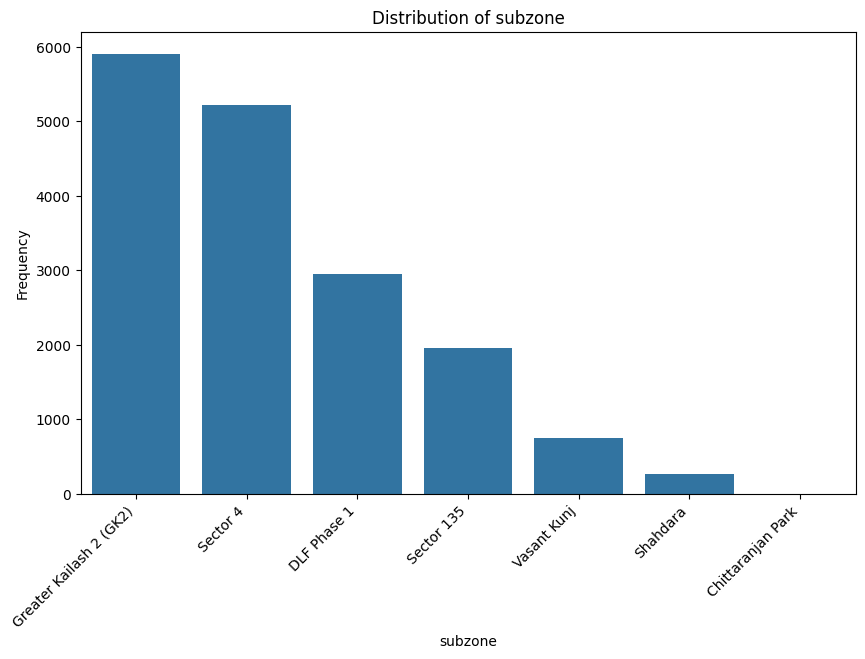

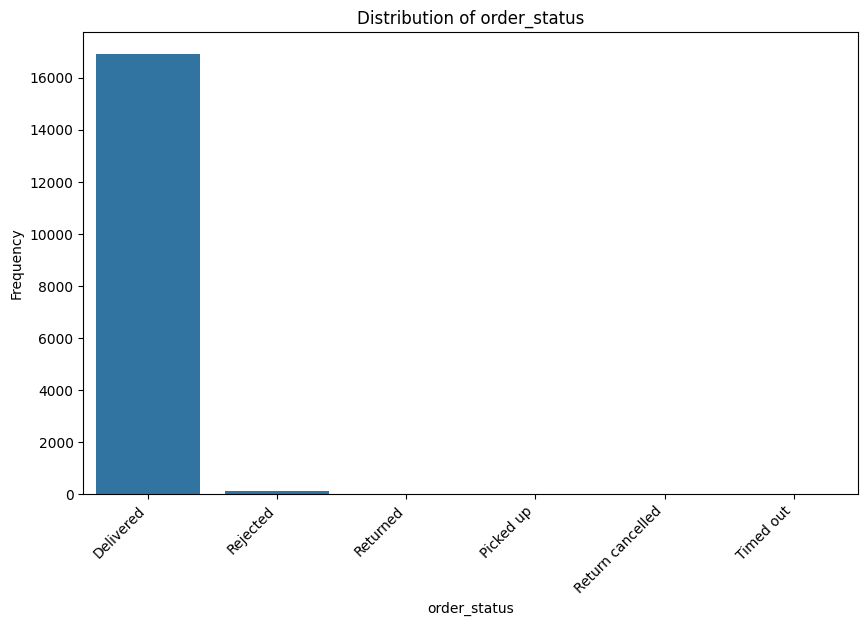

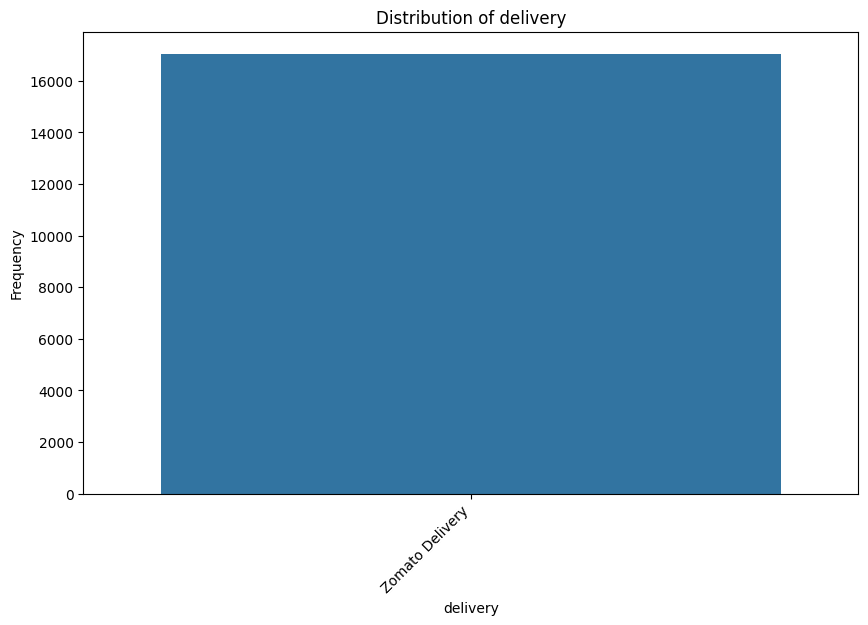

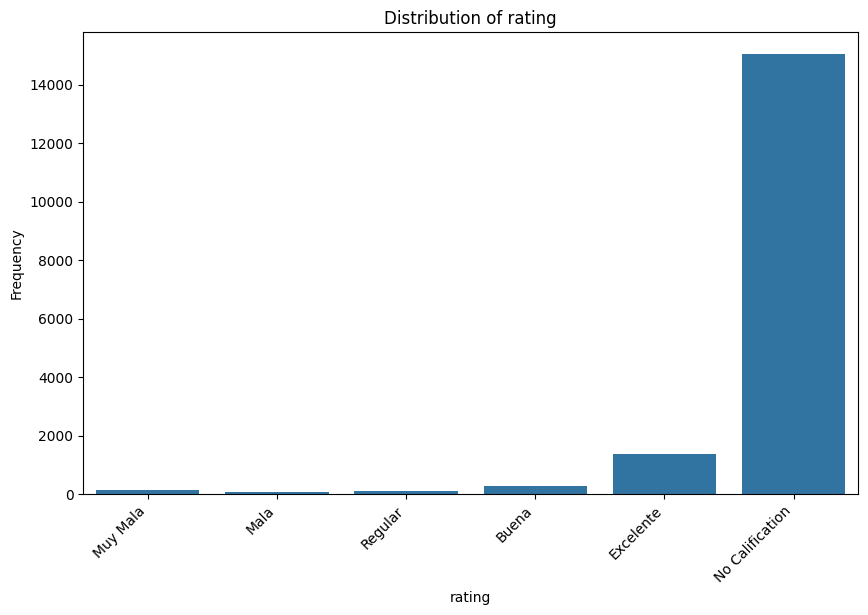

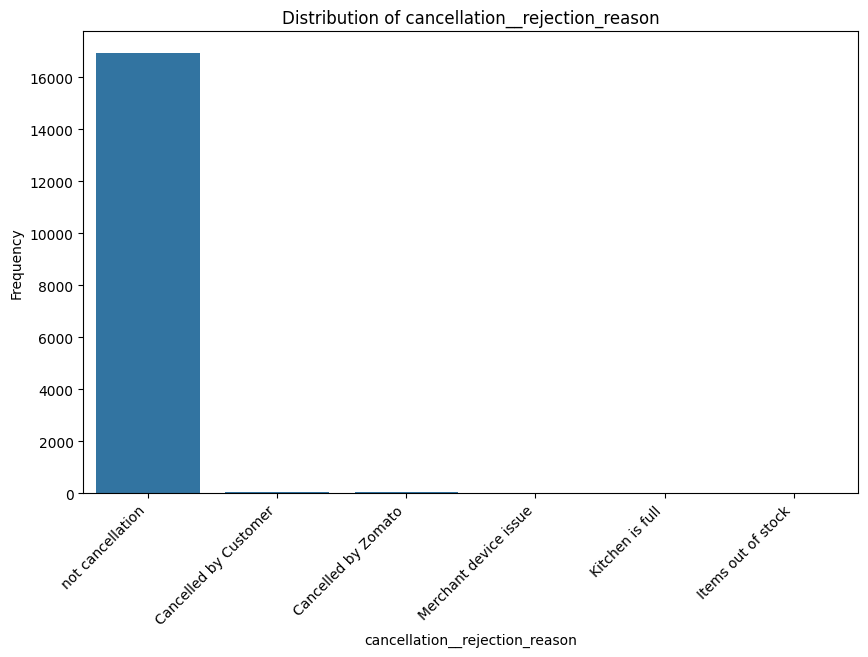

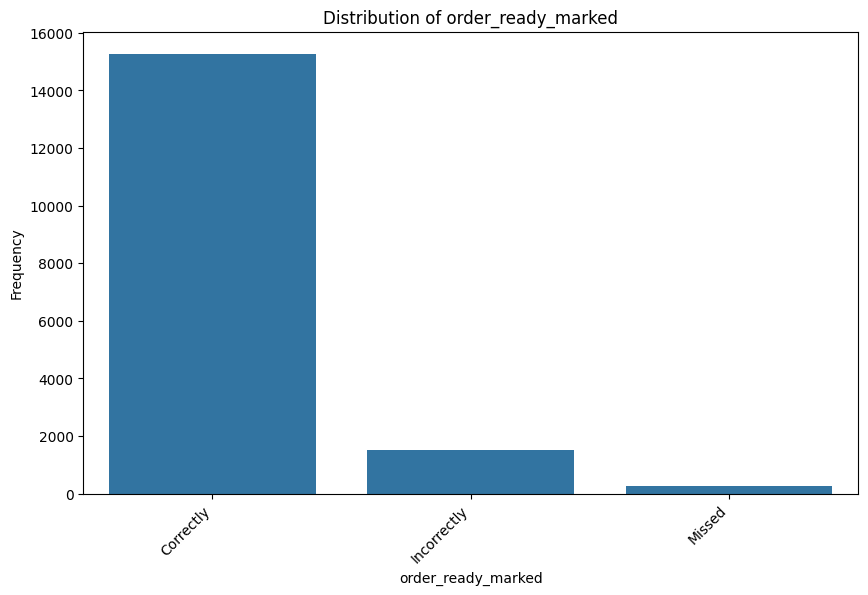

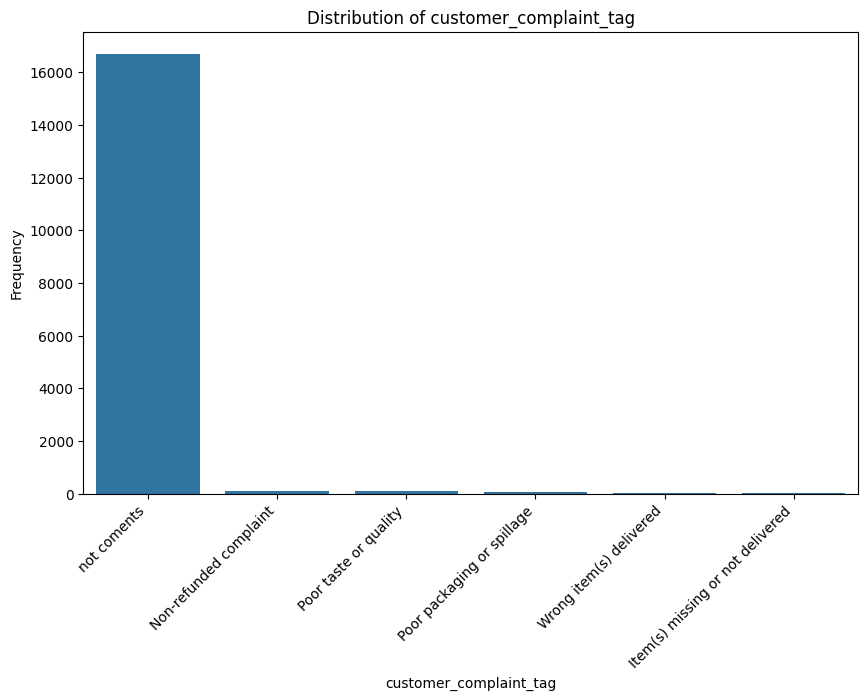

In [ ]:
categorical_cols = train_df.select_dtypes(include=['object','category']).columns
for col in categorical_cols:
    counts= train_df[col].value_counts()
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
    plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Crear un diccionario para almacenar los encoders
label_encoders = {}

# Aplicar Label Encoding a cada variable categórica
for col in categorical_cols:
    le = LabelEncoder()
    # Fit on the combined unique values from both train and test
    le.fit(pd.concat([train_df[col], test_df[col]], ignore_index=True).astype(str).unique())
    # Transform using a try-except block to handle unknown values
    try:
        train_df[col] = le.transform(train_df[col].astype(str))
        test_df[col] = le.transform(test_df[col].astype(str))
    except ValueError as e:
        # Handle unknown values (e.g., replace with a specific value or category)
        unknown_value = -1  # Or any other appropriate value
        train_df[col] = train_df[col].astype(str).apply(lambda x: le.transform([x])[0] if x in le.classes_ else unknown_value)
        test_df[col] = test_df[col].astype(str).apply(lambda x: le.transform([x])[0] if x in le.classes_ else unknown_value)
    label_encoders[col] = le  # Guardar el encoder para referencia futura


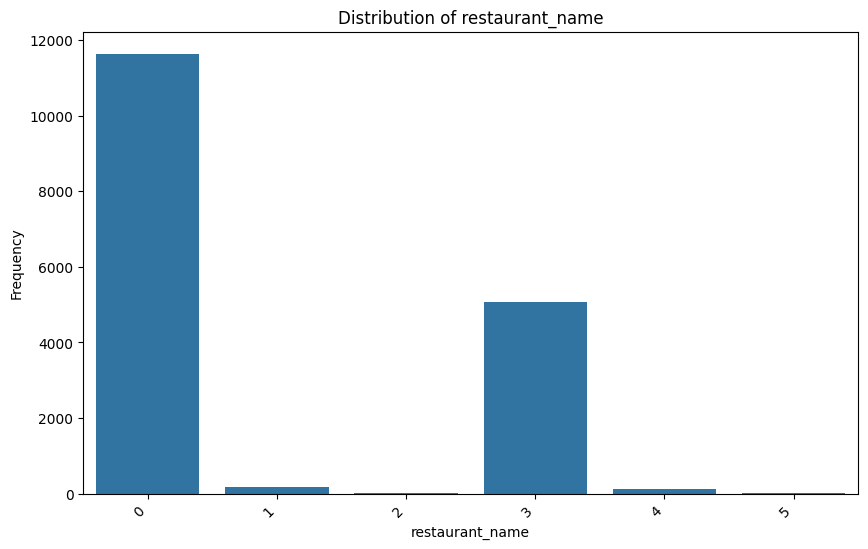

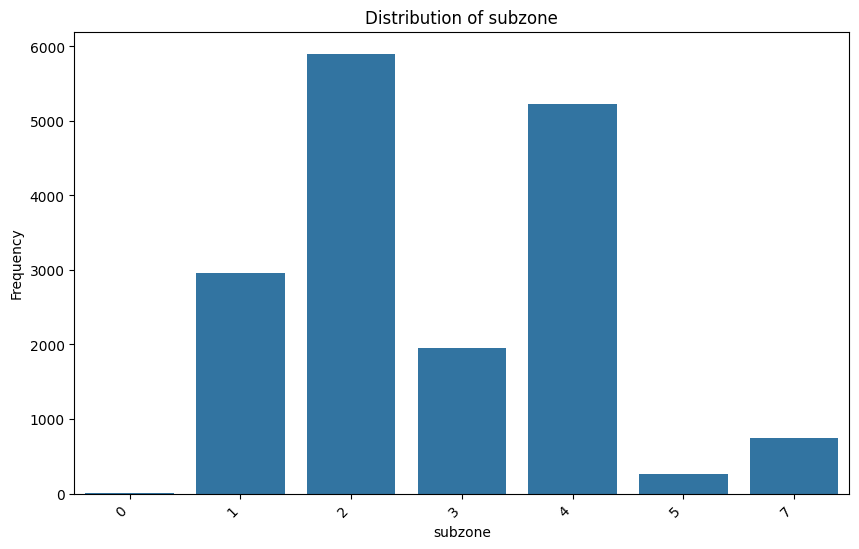

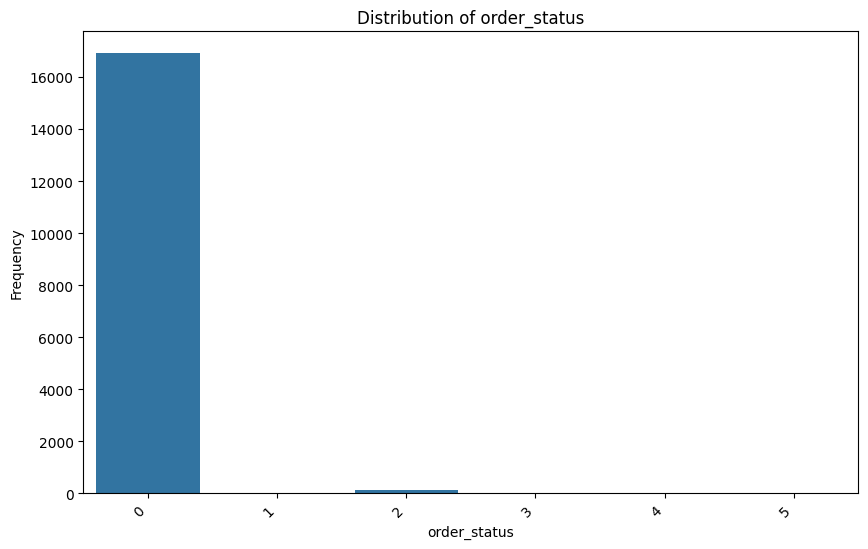

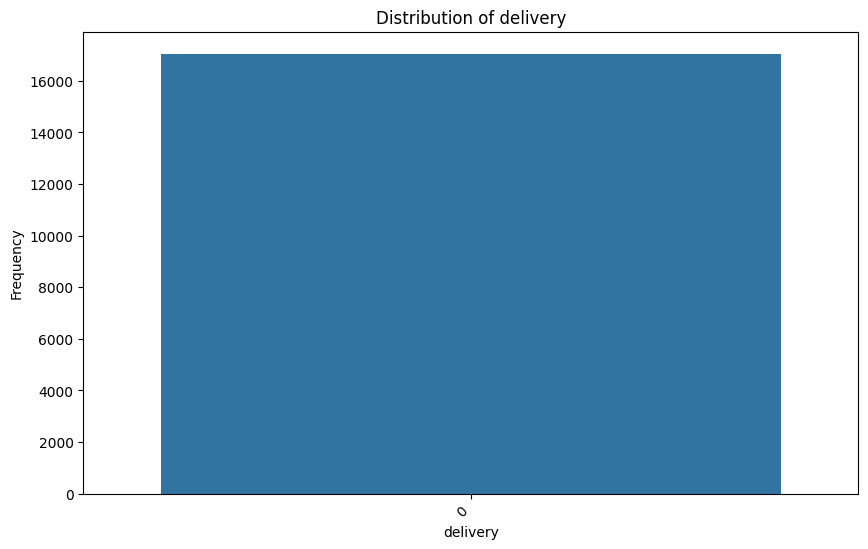

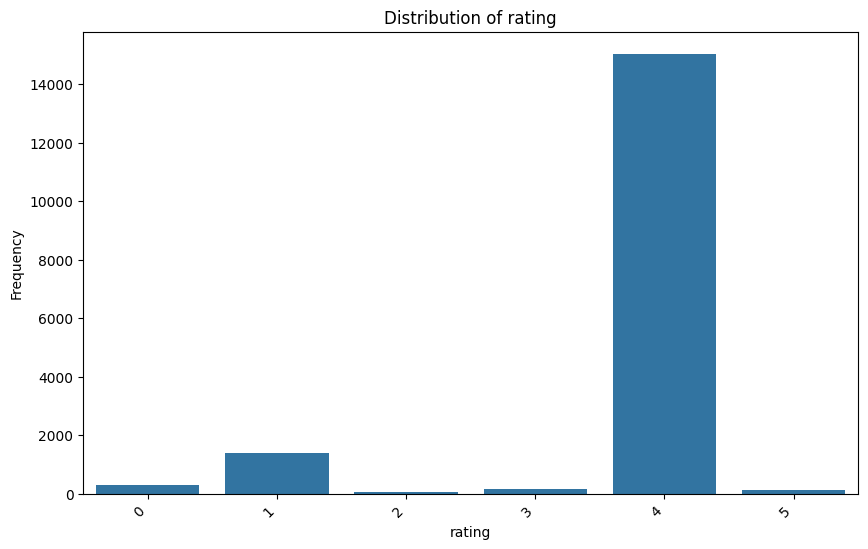

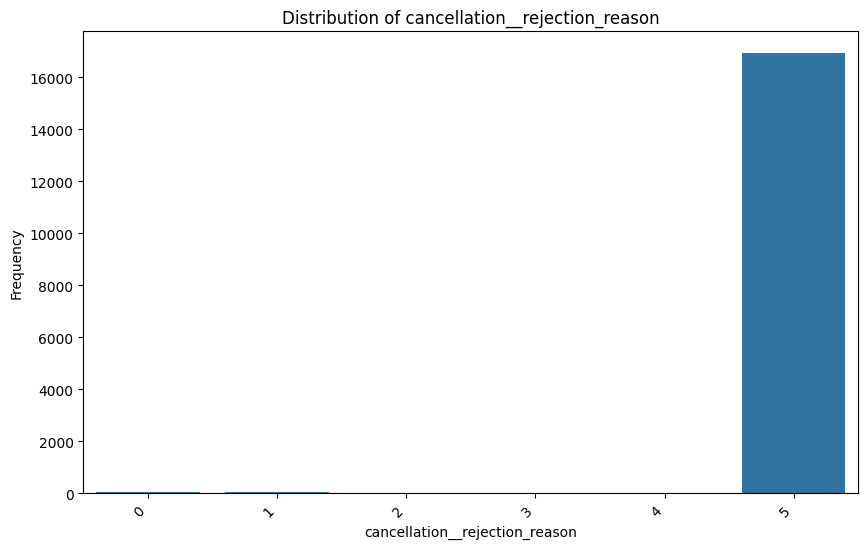

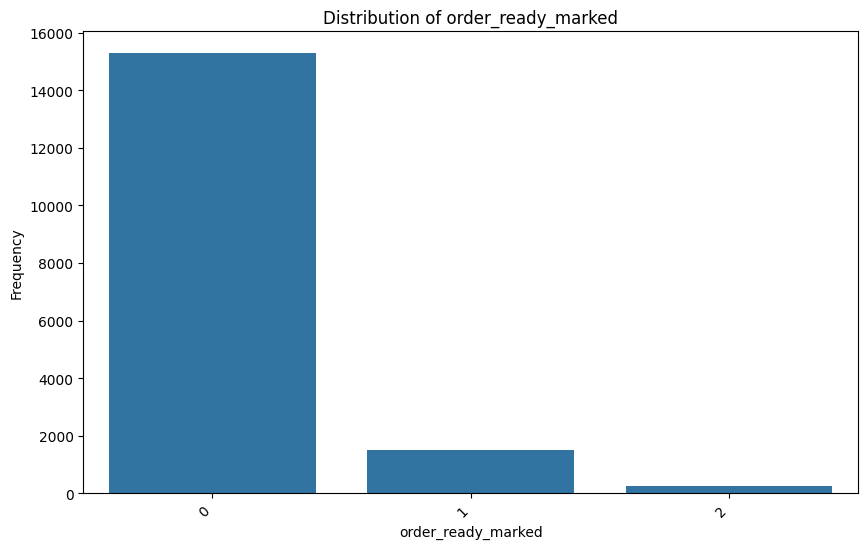

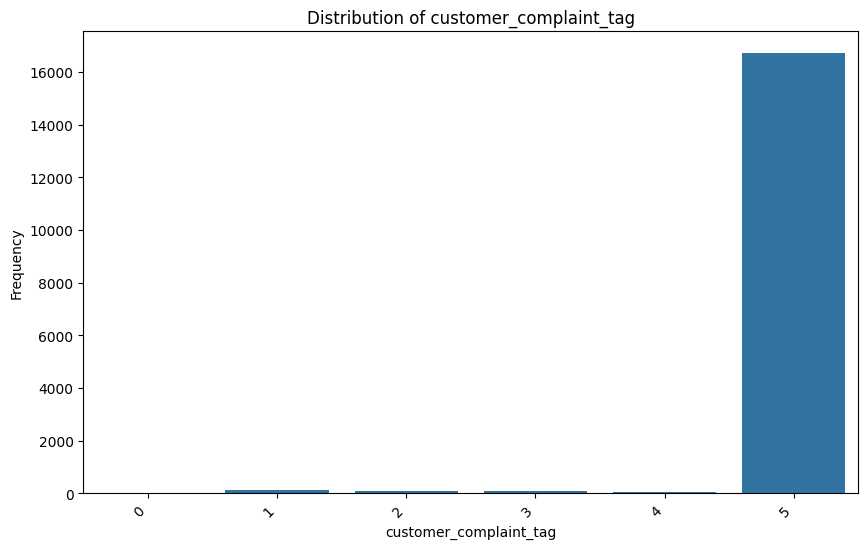

In [ ]:

for col in categorical_cols:
    counts= train_df[col].value_counts()
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
    plt.show()

# Base Line Model


In [ ]:
# # 1. Re-check for missing values in both train and test sets
print("Missing values in train_df:\n", train_df.isnull().sum())
print("\nMissing values in test_df:\n", test_df.isnull().sum())


#  X_train = train_df.drop(columns=['has_not_reorder'])  # Variables predictora 'order_placed_at'
#  y_train = train_df['has_not_reorder']  # Variable objetivo

#  X_test = test_df.drop(columns=['has_not_reorder'])  # Variables predictoras, drop 'order_placed_at'
#  y_test = test_df['has_not_reorder']  # Variable objetivo

# # # # 2️ Inicializar y entrenar el modelo
#  model = LogisticRegression(max_iter=1000, random_state=42)
#  model.fit(X_train, y_train)

# # # # 3️ Hacer predicciones
#  y_pred = model.predict(X_test)

# # # # 4️ Evaluar el modelo
#  print("Accuracy:", accuracy_score(y_test, y_pred))
#  print("Classification Report:\n", classification_report(y_test, y_pred))

Missing values in train_df:
 order_id                                0
restaurant_name                         0
subzone                                 0
order_month                             0
order_day                               0
order_hour                              0
order_dayofweek                         0
order_weekofyear                        0
order_status                            0
delivery                                0
distance                                0
bill_subtotal                           0
packaging_charges                       0
total                                   0
rating                                  0
cancellation__rejection_reason          0
restaurant_compensation_cancellation    0
restaurant_penalty_rejection            0
kpt_duration_minutes                    0
rider_wait_time_minutes                 0
order_ready_marked                      0
customer_complaint_tag                  0
number_of_products                      0
mean_

##Test

In [ ]:
# # Importar librerías necesarias
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# # 1️⃣ Definir variables predictoras (X) y la variable objetivo (y)
# X_train = train_df.drop(columns=['has_not_reorder'])  # Variables predictoras
# y_train = train_df['has_not_reorder']  # Variable objetivo

# X_test = test_df.drop(columns=['has_not_reorder'])
# y_test = test_df['has_not_reorder']

# # Verificar si hay valores nulos en las variables predictoras antes de entrenar
# if X_train.isnull().sum().sum() > 0 or X_test.isnull().sum().sum() > 0:
#     print("⚠️ Hay valores nulos en las variables predictoras. Asegúrate de imputarlos antes de entrenar el modelo.")

# # 2️⃣ Inicializar y entrenar el modelo
# model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_train, y_train)

# # 3️⃣ Hacer predicciones
# y_pred = model.predict(X_test)

# # 4️⃣ Evaluar el modelo
# print("\n📊 Evaluación del Modelo:")
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Classification Report:\n", classification_report(y_test, y_pred))
# print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))


In [ ]:
# Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1️ Definir variables predictoras (X) y la variable objetivo (y)
X_train = train_df.drop(columns=['has_not_reorder', 'order_id'])
y_train = train_df['has_not_reorder']

X_test = test_df.drop(columns=['has_not_reorder', 'order_id'])
y_test = test_df['has_not_reorder']

# 2️ Entrenar el modelo nuevamente
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# 3 Hacer predicciones
y_pred = clf.predict(X_test)

Matriz de Confusión


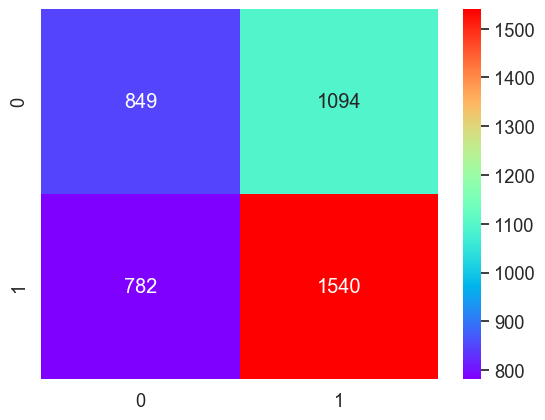

Comparación de Accuracy entre las muestras de entrenamiento y test:
Accuracy (muestra de test): 0.56
Accuracy (muestra de entrenamiento): 0.57
Resto de métricas para la muestra de test:
Precision: 0.58
Recall: 0.66
F1 score: 0.62
AUC score: 0.60


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report,confusion_matrix #Importamos la matriz de confusión
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

cm = confusion_matrix(y_test,clf.predict(X_test))
print('Matriz de Confusión')
sns.set(font_scale = 1.2)
sns.heatmap(cm, annot = True,fmt = 'd', cmap='rainbow')
plt.show()

print('Comparación de Accuracy entre las muestras de entrenamiento y test:')
print(f'Accuracy (muestra de test): {"{:.2f}".format(accuracy_score(y_test, clf.predict(X_test) ))}')
print(f'Accuracy (muestra de entrenamiento): {"{:.2f}".format(accuracy_score(y_train, clf.predict(X_train) ))}')
print('Resto de métricas para la muestra de test:')
print("Precision:", "{:.2f}".format(precision_score(y_test,clf.predict(X_test))))
print("Recall:", "{:.2f}".format(recall_score(y_test, clf.predict(X_test))))
print("F1 score:","{:.2f}".format( f1_score(y_test, clf.predict(X_test))))
y_probs = clf.predict_proba(X_test) # cálculo de las probabilidades de pertenencia a cada clase para todas las observaciones de la muestra de test
y_probs_1 = y_probs[:, 1] # probabilidades de la clase y = 1 para todos los registros que se requiere para la métrica AUC
print(f'AUC score: {"{:.2f}".format(roc_auc_score(y_test, y_probs_1))}')

In [ ]:

# 4 Evaluar el modelo
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# 5 Graficar comparación entre valores reales y predicciones
plt.figure(figsize=(6, 4))

# Contar valores reales y predicciones
real_counts = pd.Series(y_test).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()

# Crear un DataFrame para visualización
df_plot = pd.DataFrame({'Real': real_counts, 'Predicho': pred_counts})

# Graficar
df_plot.plot(kind='bar', figsize=(8, 5), color=['blue', 'orange'])

# Etiquetas y título
plt.xlabel("Clases (0 = Recompra, 1 = No Recompra)")
plt.ylabel("Cantidad de observaciones")
plt.title("Comparación de valores reales vs predicciones")
plt.legend(["Real", "Predicho"])

# Mostrar gráfico
plt.show()


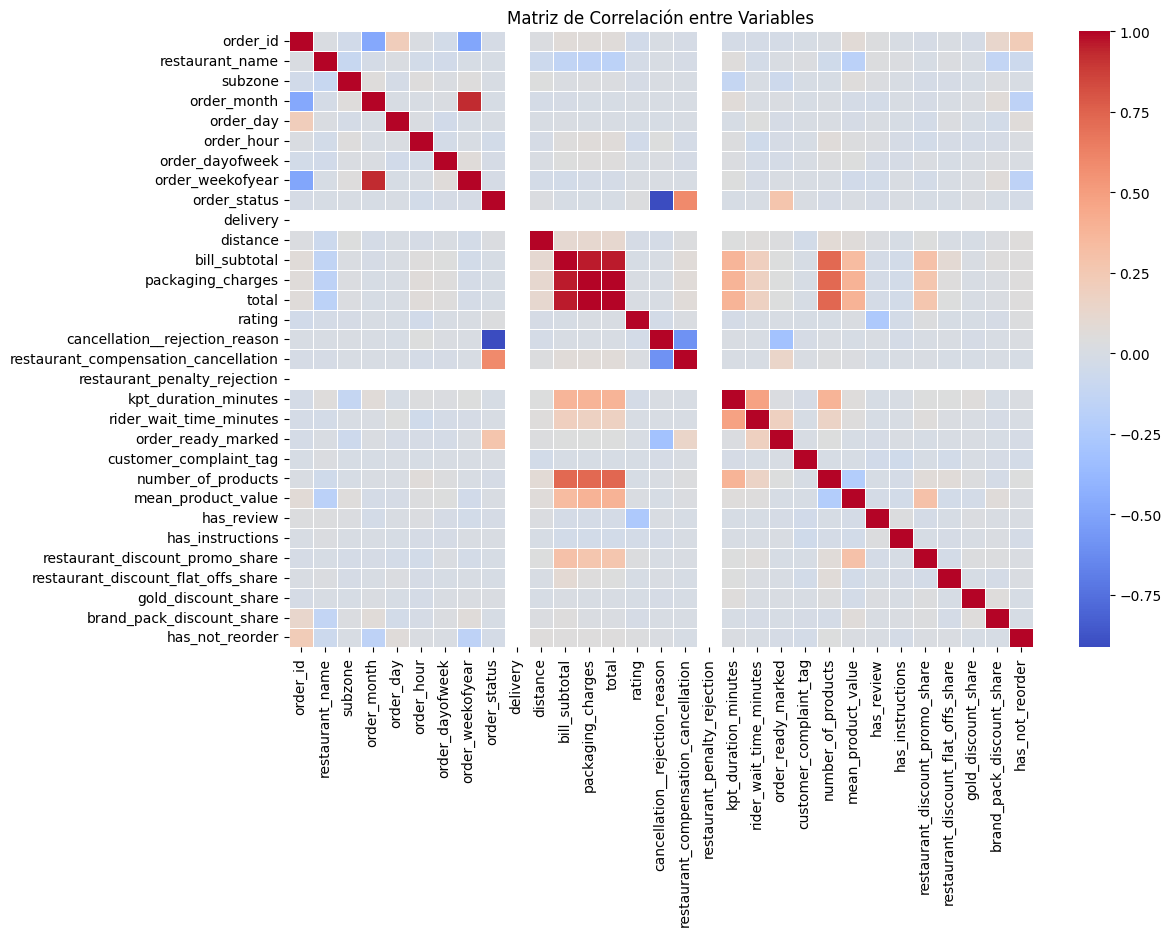

In [ ]:
# Calcular la matriz de correlación
correlation_matrix = train_df.corr()

# Graficar la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)

# Título
plt.title("Matriz de Correlación entre Variables")

# Mostrar gráfico
plt.show()

# Selection Varibles

In [ ]:
# Verificar que train_df y test_df están cargados
print("Dimensiones actuales de train_df:", train_df.shape)
print("Dimensiones actuales de test_df:", test_df.shape)

# Definir columnas a eliminar
columns_to_drop = ['order_id',  'bill_subtotal', 'number_of_products','order_weekofyear']

# Eliminar columnas en ambos DataFrames
train_df_v2 = train_df.drop(columns=["order_id"])
test_df_v2 = test_df.drop(columns=['order_id'])

print("Columnas eliminadas:", columns_to_drop)
print("Nuevas dimensiones de train_df_v2:", train_df_v2.shape)
print("Nuevas dimensiones de test_df_v2:", test_df_v2.shape)

# Importar modelo y métricas
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Definir variables predictoras y objetivo
X_train_v2 = train_df_v2.drop(columns=['has_not_reorder'])
y_train_v2 = train_df_v2['has_not_reorder']

X_test_v2 = test_df_v2.drop(columns=['has_not_reorder'])
y_test_v2 = test_df_v2['has_not_reorder']

# Inicializar y entrenar modelo Random Forest
model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v2.fit(X_train_v2, y_train_v2)

# Hacer predicciones
y_pred_v2 = model_v2.predict(X_test_v2)

# Evaluar el modelo
print("\n📊 Evaluación del Modelo Random Forest:")
print("Accuracy:", accuracy_score(y_test_v2, y_pred_v2))
print("Classification Report:\n", classification_report(y_test_v2, y_pred_v2))
print("Matriz de Confusión:\n", confusion_matrix(y_test_v2, y_pred_v2))


Dimensiones actuales de train_df: (17056, 31)
Dimensiones actuales de test_df: (4265, 31)
Columnas eliminadas: ['order_id', 'bill_subtotal', 'number_of_products', 'order_weekofyear']
Nuevas dimensiones de train_df_v2: (17056, 30)
Nuevas dimensiones de test_df_v2: (4265, 30)

📊 Evaluación del Modelo Random Forest:
Accuracy: 0.6157092614302462
Classification Report:
               precision    recall  f1-score   support

       False       0.58      0.56      0.57      1943
        True       0.64      0.66      0.65      2322

    accuracy                           0.62      4265
   macro avg       0.61      0.61      0.61      4265
weighted avg       0.61      0.62      0.62      4265

Matriz de Confusión:
 [[1095  848]
 [ 791 1531]]


In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model_v2, X_train, y_train, n_repeats=30, random_state=42
)

perm_importance = pd.Series(result.importances_mean, index=X_train.columns).sort_values(ascending=False)
perm_importance
# Plotting
plt.figure(figsize=(8, 5))
perm_importance.sort_values().plot(kind='barh')
plt.xlabel('Coefficient Magnitude')
plt.title('Feature Importance (Logistic Regression)')
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
y_probs_1

array([0.6431846 , 0.47288141, 0.49162581, ..., 0.65014651, 0.4621849 ,
       0.64259148])

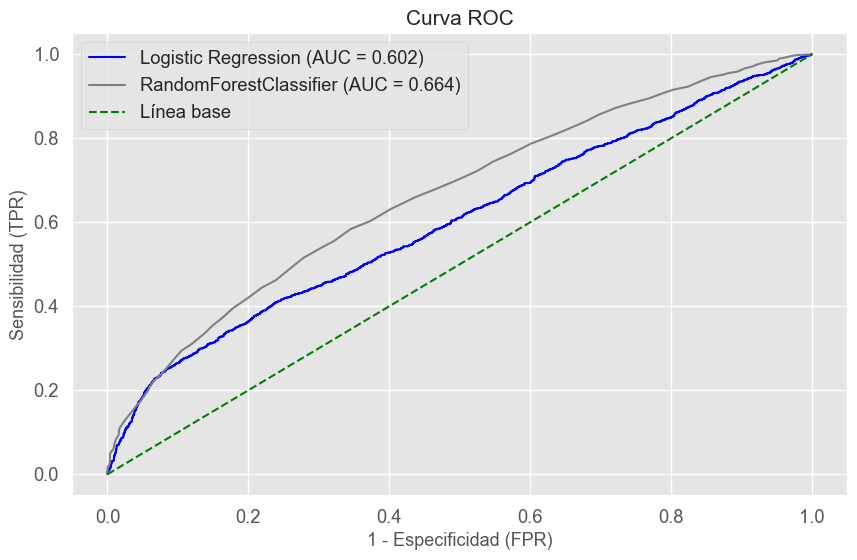

In [ ]:
y_probs = clf.predict_proba(X_test) # cálculo de las probabilidades de pertenencia a cada clase para todas las observaciones de la muestra de test
y_probs_1 = y_probs[:, 1] # probabilidades de la clase y = 1 para todos los registros que se requiere para la métrica AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_1)
#Métrica AUC
auc = round(roc_auc_score(y_test, y_probs_1), 3)


y_probs_2 = model_v2.predict_proba(X_test) # cálculo de las probabilidades de pertenencia a cada clase para todas las observaciones de la muestra de test
y_probs_2 = y_probs_2[:, 1] # probabilidades de la clase y = 1 para todos los registros que se requiere para la métrica AUC
fpr_2, tpr_2, thresholds = roc_curve(y_test_v2, y_probs_2)
#Métrica AUC
auc_2 = round(roc_auc_score(y_test, y_probs_2), 3)


#Representación gráfica de la curva de ROC
fig, ax = plt.subplots(figsize=(10, 6))
plt.style.use('ggplot')
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc})', color='blue')
plt.plot(fpr_2, tpr_2, label=f'RandomForestClassifier (AUC = {auc_2})', color='gray')


#Representamos la línea base
plt.plot([0, 1], [0, 1], linestyle='--', color='green', label='Línea base')
plt.xlabel('1 - Especificidad (FPR)', size=13)
plt.ylabel('Sensibilidad (TPR)', size=13)
plt.title('Curva ROC', size=15)
plt.legend(loc='best')
plt.show()